In [2]:
!pip3 install -r requirements.txt


[notice] A new release of pip is available: 23.1.2 -> 26.1.2
[notice] To update, run: python3.10 -m pip install --upgrade pip


In [3]:
import sqlite3
import hashlib
import pandas as pd
import networkx as nx
import plotly.express as px
import matplotlib.pyplot as plt

conn = sqlite3.connect('../data/claritypay.db')

def sha256_hash(val):
    if not val:
        return None
    return hashlib.sha256(str(val).encode('utf-8')).hexdigest()

conn.create_function("sha256", 1, sha256_hash)

In [4]:
df_customers = pd.read_sql_query("SELECT * FROM masked_customers LIMIT 5;", conn)
df_customers

,customer_id,signup_at,region,risk_band,credit_limit_usd,status,tax_id_hashed,dob_masked,email_masked,is_confirmed_fraud
0,1,2026-05-24,EU,B,3300.0,active,9a13ba4c427d1c116edb04e1cdce3f63db2708ca525f18...,1968-01-01,p***@inbox.example,0
1,2,2025-02-07,NA,B,2450.0,defaulted,1300ce4a9ae11209b3297b57fe0f28c33620ea138255c3...,1997-01-01,a***@test.example,0
2,3,2025-12-13,NA,D,1350.0,defaulted,e934817dd5f61d6106785d479fe2b47d389c6bd13fe479...,1968-01-01,p***@post.example,0
3,4,2026-01-06,NA,C,2600.0,active,effac0218ad7e440f0686844dfddabe4aa19c102ab31be...,1972-01-01,c***@mail.example,0
4,5,2026-01-25,EU,B,3350.0,active,b2a1ce9c7edeafaa752b4e3b48fa77e48a0518b7fff229...,1963-01-01,v***@post.example,0


In [5]:
def plot_vintage_curves(merchant_id=None):
    # Parameterized SQL query for A1 cohort vintage curves
    query = """
    WITH installment_months AS (
        SELECT 
            strftime('%Y-%m', p.created_at) AS cohort_month,
            (
                (strftime('%Y', i.due_date) - strftime('%Y', p.created_at)) * 12 + 
                (strftime('%m', i.due_date) - strftime('%m', p.created_at))
            ) AS months_on_book,
            i.status
        FROM plans p
        JOIN installments i ON p.plan_id = i.plan_id
        WHERE i.due_date <= '2026-07-01'
          AND (? IS NULL OR p.merchant_id = ?)
    ),
    mob_aggregates AS (
        SELECT 
            cohort_month,
            months_on_book,
            COUNT(*) AS due_at_mob,
            SUM(CASE WHEN status IN ('late', 'missed', 'written_off') THEN 1 ELSE 0 END) AS default_at_mob
        FROM installment_months
        GROUP BY 1, 2
    )
    SELECT 
        cohort_month,
        months_on_book,
        SUM(due_at_mob) OVER (
            PARTITION BY cohort_month
            ORDER BY months_on_book ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ) AS installments_due,
        ROUND(
            CAST(
                SUM(default_at_mob) OVER (
                    PARTITION BY cohort_month
                    ORDER BY months_on_book ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
                ) AS REAL
            ) / SUM(due_at_mob) OVER (
                PARTITION BY cohort_month
                ORDER BY months_on_book ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
            ),
            4
        ) AS cumulative_default_rate
    FROM mob_aggregates
    ORDER BY 1, 2;
    """
    
    merchant_id = None # Change merchant_id if required (None = Global)
    df = pd.read_sql_query(query, conn, params=(merchant_id, merchant_id))
    
    title_suffix = f" for Merchant {merchant_id}" if merchant_id else " (Global)"
    fig = px.line(
        df,
        x='months_on_book',
        y='cumulative_default_rate',
        color='cohort_month',
        markers=True,
        labels={
            'months_on_book': 'Months on Book (MOB)',
            'cumulative_default_rate': 'Cumulative Default Rate (CDR)',
            'cohort_month': 'Cohort Month'
        },
        title=f"Cohort Vintage Default Curves{title_suffix}"
    )
    
    fig.update_layout(
        yaxis_tickformat='.2%',
        hovermode='x unified',
        template='plotly_white'
    )
    return fig

fig_global = plot_vintage_curves()
fig_global.show()

Plotting identity cluster for component: c_1371


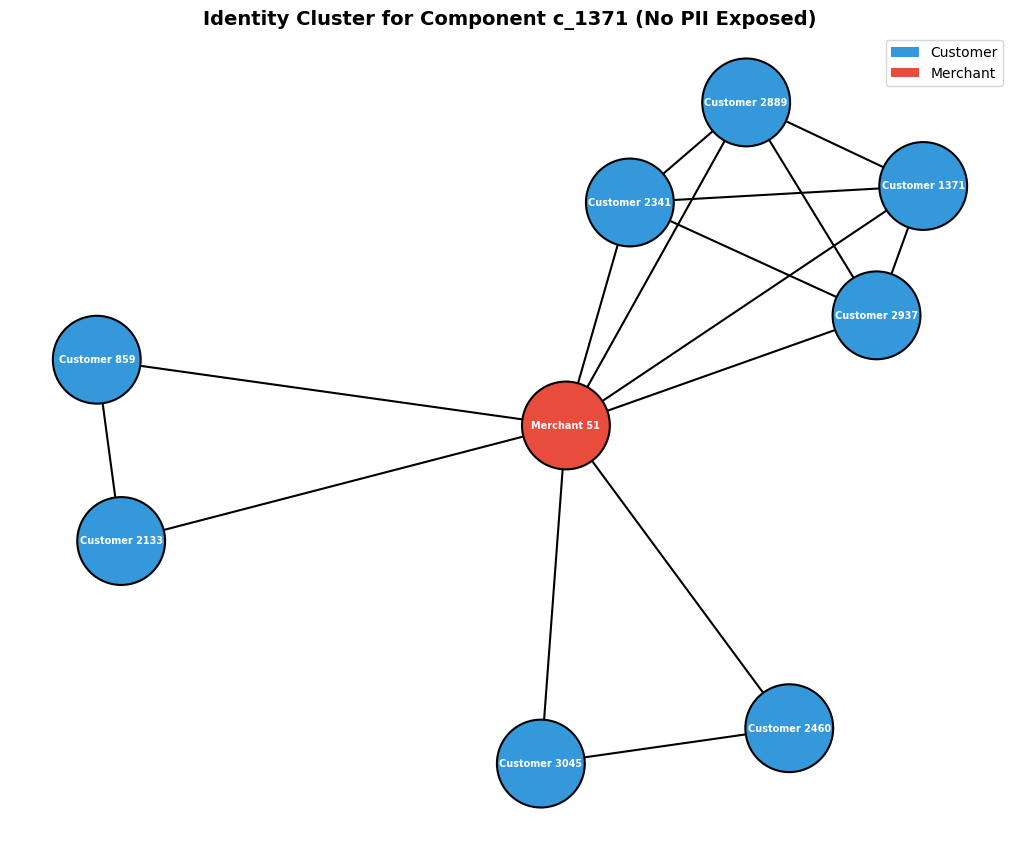

In [7]:
def plot_identity_cluster(component_id=None, merchant_id=None):
    # Run B1 logic to compute components
    # Extract nodes and edges for the targeted cluster
    
    query_nodes = """
    WITH node_identifiers AS (
        SELECT 'customer' AS node_type, customer_id AS node_id, 'c_' || customer_id AS node_uid, 'email' AS id_type, email AS id_value
        FROM customers WHERE email IS NOT NULL AND email != ''
        UNION ALL
        SELECT 'merchant' AS node_type, merchant_id AS node_id, 'm_' || merchant_id AS node_uid, 'email' AS id_type, owner_email AS id_value
        FROM merchants WHERE owner_email IS NOT NULL AND owner_email != ''
        UNION ALL
        SELECT 'customer' AS node_type, customer_id AS node_id, 'c_' || customer_id AS node_uid, 'tax_id' AS id_type, tax_id AS id_value
        FROM customers WHERE tax_id IS NOT NULL AND tax_id != ''
        UNION ALL
        SELECT 'merchant' AS node_type, merchant_id AS node_id, 'm_' || merchant_id AS node_uid, 'tax_id' AS id_type, owner_tax_id AS id_value
        FROM merchants WHERE owner_tax_id IS NOT NULL AND owner_tax_id != ''
        UNION ALL
        SELECT 'customer' AS node_type, customer_id AS node_id, 'c_' || customer_id AS node_uid, 'card' AS id_type, card_fingerprint AS id_value
        FROM payment_instruments WHERE instrument_type = 'card' AND card_fingerprint IS NOT NULL AND card_fingerprint != ''
        UNION ALL
        SELECT 'merchant' AS node_type, merchant_id AS node_id, 'm_' || merchant_id AS node_uid, 'card' AS id_type, business_card_fingerprint AS id_value
        FROM merchants WHERE business_card_fingerprint IS NOT NULL AND business_card_fingerprint != ''
        UNION ALL
        SELECT 'customer' AS node_type, customer_id AS node_id, 'c_' || customer_id AS node_uid, 'bank' AS id_type, bank_account_fingerprint AS id_value
        FROM payment_instruments WHERE instrument_type = 'bank' AND bank_account_fingerprint IS NOT NULL AND bank_account_fingerprint != ''
    ),
    edges AS (
        SELECT DISTINCT
            a.node_uid AS source_uid,
            b.node_uid AS target_uid
        FROM node_identifiers a
        JOIN node_identifiers b 
            ON a.id_type = b.id_type AND a.id_value = b.id_value
        WHERE a.node_uid != b.node_uid
    ),
    initial_nodes AS (
        SELECT 'customer' AS node_type, customer_id AS node_id, 'c_' || customer_id AS node_uid FROM customers
        UNION ALL
        SELECT 'merchant' AS node_type, merchant_id AS node_id, 'm_' || merchant_id AS node_uid FROM merchants
    ),
    graph_traversal AS (
        SELECT 
            node_uid AS root_uid,
            node_uid AS current_uid,
            ',' || node_uid || ',' AS visited_path,
            0 AS depth
        FROM initial_nodes
        UNION ALL
        SELECT 
            gt.root_uid,
            e.target_uid AS current_uid,
            gt.visited_path || e.target_uid || ',' AS visited_path,
            gt.depth + 1 AS depth
        FROM graph_traversal gt
        JOIN edges e ON gt.current_uid = e.source_uid
        WHERE gt.depth < 10 
          AND INSTR(gt.visited_path, ',' || e.target_uid || ',') = 0
    ),
    components AS (
        SELECT 
            i.node_type,
            i.node_id,
            i.node_uid,
            MIN(gt.root_uid) AS component_id
        FROM (
            SELECT DISTINCT current_uid AS node_uid, root_uid FROM graph_traversal
        ) gt
        JOIN initial_nodes i ON gt.node_uid = i.node_uid
        GROUP BY 1, 2, 3
    ),
    target_comp AS (
        SELECT DISTINCT component_id 
        FROM components 
        WHERE (? IS NOT NULL AND component_id = ?)
           OR (? IS NOT NULL AND node_uid = 'm_' || ?)
    )
    SELECT c.node_uid, c.node_type, c.node_id, c.component_id
    FROM components c
    JOIN target_comp tc ON c.component_id = tc.component_id;
    """
    
    # Read the target component nodes
    df_nodes = pd.read_sql_query(query_nodes, conn, params=(component_id, component_id, merchant_id, merchant_id))
    
    if df_nodes.empty:
        print("No matching cluster found.")
        return
    
    actual_comp_id = df_nodes['component_id'].iloc[0]
    node_uids_list = df_nodes['node_uid'].tolist()
    placeholders = ",".join(["?"] * len(node_uids_list))
    
    query_edges = f"""
    WITH node_identifiers AS (
        SELECT 'customer' AS node_type, customer_id AS node_id, 'c_' || customer_id AS node_uid, 'email' AS id_type, email AS id_value
        FROM customers WHERE email IS NOT NULL AND email != ''
        UNION ALL
        SELECT 'merchant' AS node_type, merchant_id AS node_id, 'm_' || merchant_id AS node_uid, 'email' AS id_type, owner_email AS id_value
        FROM merchants WHERE owner_email IS NOT NULL AND owner_email != ''
        UNION ALL
        SELECT 'customer' AS node_type, customer_id AS node_id, 'c_' || customer_id AS node_uid, 'tax_id' AS id_type, tax_id AS id_value
        FROM customers WHERE tax_id IS NOT NULL AND tax_id != ''
        UNION ALL
        SELECT 'merchant' AS node_type, merchant_id AS node_id, 'm_' || merchant_id AS node_uid, 'tax_id' AS id_type, owner_tax_id AS id_value
        FROM merchants WHERE owner_tax_id IS NOT NULL AND owner_tax_id != ''
        UNION ALL
        SELECT 'customer' AS node_type, customer_id AS node_id, 'c_' || customer_id AS node_uid, 'card' AS id_type, card_fingerprint AS id_value
        FROM payment_instruments WHERE instrument_type = 'card' AND card_fingerprint IS NOT NULL AND card_fingerprint != ''
        UNION ALL
        SELECT 'merchant' AS node_type, merchant_id AS node_id, 'm_' || merchant_id AS node_uid, 'card' AS id_type, business_card_fingerprint AS id_value
        FROM merchants WHERE business_card_fingerprint IS NOT NULL AND business_card_fingerprint != ''
        UNION ALL
        SELECT 'customer' AS node_type, customer_id AS node_id, 'c_' || customer_id AS node_uid, 'bank' AS id_type, bank_account_fingerprint AS id_value
        FROM payment_instruments WHERE instrument_type = 'bank' AND bank_account_fingerprint IS NOT NULL AND bank_account_fingerprint != ''
    )
    SELECT DISTINCT
        a.node_uid AS source_uid,
        b.node_uid AS target_uid
    FROM node_identifiers a
    JOIN node_identifiers b 
        ON a.id_type = b.id_type AND a.id_value = b.id_value
    WHERE a.node_uid != b.node_uid
      AND a.node_uid IN ({placeholders})
      AND b.node_uid IN ({placeholders});
    """
    
    df_edges = pd.read_sql_query(query_edges, conn, params=node_uids_list + node_uids_list)
    
    # Draw the graph
    G = nx.Graph()
    
    for _, row in df_nodes.iterrows():
        label = f"{row['node_type'].capitalize()} {row['node_id']}"
        G.add_node(row['node_uid'], label=label, type=row['node_type'])
        
    for _, row in df_edges.iterrows():
        G.add_edge(row['source_uid'], row['target_uid'])
        
    pos = nx.spring_layout(G, seed=42)
    labels = nx.get_node_attributes(G, 'label')
    types = nx.get_node_attributes(G, 'type')
    
    node_colors = []
    for node in G.nodes():
        if types[node] == 'customer':
            node_colors.append('#3498db')  # blue
        else:
            node_colors.append('#e74c3c')  # red
            
    plt.figure(figsize=(10, 8))
    nx.draw(
        G, pos,
        node_color=node_colors,
        labels=labels,
        with_labels=True,
        node_size=4000,
        font_size=7,
        font_color='white',
        font_weight='bold',
        edge_color='black',
        width=1.5,
        edgecolors='black',
        linewidths=1.5
    )
    
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#3498db', label='Customer'),
        Patch(facecolor='#e74c3c', label='Merchant')
    ]
    plt.legend(handles=legend_elements, loc='upper right')
    plt.title(f"Identity Cluster for Component {actual_comp_id} (No PII Exposed)", fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()

# Find a component with size > 1 dynamically to test plotting
df_large_comps = pd.read_sql_query("""
    WITH node_identifiers AS (
        SELECT 'customer' AS node_type, customer_id AS node_id, 'c_' || customer_id AS node_uid, 'email' AS id_type, email AS id_value
        FROM customers WHERE email IS NOT NULL AND email != ''
        UNION ALL
        SELECT 'merchant' AS node_type, merchant_id AS node_id, 'm_' || merchant_id AS node_uid, 'email' AS id_type, owner_email AS id_value
        FROM merchants WHERE owner_email IS NOT NULL AND owner_email != ''
        UNION ALL
        SELECT 'customer' AS node_type, customer_id AS node_id, 'c_' || customer_id AS node_uid, 'tax_id' AS id_type, tax_id AS id_value
        FROM customers WHERE tax_id IS NOT NULL AND tax_id != ''
        UNION ALL
        SELECT 'merchant' AS node_type, merchant_id AS node_id, 'm_' || merchant_id AS node_uid, 'tax_id' AS id_type, owner_tax_id AS id_value
        FROM merchants WHERE owner_tax_id IS NOT NULL AND owner_tax_id != ''
        UNION ALL
        SELECT 'customer' AS node_type, customer_id AS node_id, 'c_' || customer_id AS node_uid, 'card' AS id_type, card_fingerprint AS id_value
        FROM payment_instruments WHERE instrument_type = 'card' AND card_fingerprint IS NOT NULL AND card_fingerprint != ''
        UNION ALL
        SELECT 'merchant' AS node_type, merchant_id AS node_id, 'm_' || merchant_id AS node_uid, 'card' AS id_type, business_card_fingerprint AS id_value
        FROM merchants WHERE business_card_fingerprint IS NOT NULL AND business_card_fingerprint != ''
        UNION ALL
        SELECT 'customer' AS node_type, customer_id AS node_id, 'c_' || customer_id AS node_uid, 'bank' AS id_type, bank_account_fingerprint AS id_value
        FROM payment_instruments WHERE instrument_type = 'bank' AND bank_account_fingerprint IS NOT NULL AND bank_account_fingerprint != ''
    ),
    edges AS (
        SELECT DISTINCT
            a.node_uid AS source_uid,
            b.node_uid AS target_uid
        FROM node_identifiers a
        JOIN node_identifiers b 
            ON a.id_type = b.id_type AND a.id_value = b.id_value
        WHERE a.node_uid != b.node_uid
    ),
    initial_nodes AS (
        SELECT 'customer' AS node_type, customer_id AS node_id, 'c_' || customer_id AS node_uid FROM customers
        UNION ALL
        SELECT 'merchant' AS node_type, merchant_id AS node_id, 'm_' || merchant_id AS node_uid FROM merchants
    ),
    graph_traversal AS (
        SELECT 
            node_uid AS root_uid,
            node_uid AS current_uid,
            ',' || node_uid || ',' AS visited_path,
            0 AS depth
        FROM initial_nodes
        UNION ALL
        SELECT 
            gt.root_uid,
            e.target_uid AS current_uid,
            gt.visited_path || e.target_uid || ',' AS visited_path,
            gt.depth + 1 AS depth
        FROM graph_traversal gt
        JOIN edges e ON gt.current_uid = e.source_uid
        WHERE gt.depth < 10 
          AND INSTR(gt.visited_path, ',' || e.target_uid || ',') = 0
    ),
    components AS (
        SELECT 
            node_uid,
            MIN(root_uid) AS component_id
        FROM (
            SELECT DISTINCT current_uid AS node_uid, root_uid FROM graph_traversal
        ) gt
        GROUP BY 1
    )
    SELECT component_id, COUNT(*) as cnt 
    FROM components 
    GROUP BY component_id 
    HAVING cnt > 1 
    ORDER BY cnt DESC;

""", conn)

if not df_large_comps.empty:
    sample_component = df_large_comps['component_id'].iloc[0]
    print(f"Plotting identity cluster for component: {sample_component}")
    plot_identity_cluster(component_id=sample_component)
else:
    print("No clusters of size > 1 found in database.")

In [12]:
df_large_comps

,component_id,cnt
0,c_1371,9
1,c_1161,7
2,c_11,6
3,c_1018,5
4,c_2999,3
5,c_520,2
6,c_487,2
7,c_384,2
8,c_335,2
9,c_323,2
